# 07b — Scenario Analytics

**Input**: `scenarios.duckdb` (notebook 06)  
**Outputs**: analytical figures saved to `data/figures/`

Queries the 10,000-scenario DuckDB database to characterise the synthetic
distribution before it enters the downstream control and hedging notebooks.
All heavy lifting is SQL — pandas is used only for plotting.

## Sections
1. Regime distribution — generated vs real-world frequencies
2. Conditioning scalars by regime — price, vol, wind, imbalance
3. Log-signature distributions by regime — violin plots
4. Importance-weighted reweighting — effect on scalar means
5. Log-signature correlation structure by regime
6. Scenario sampling patterns — demonstrating query patterns for 07a/07d

## Cell 1 — Mount and install

In [44]:
%pip install duckdb --quiet

from google.colab import drive
drive.mount("/content/drive")
from pathlib import Path
DATA_DIR = Path("/content/drive/MyDrive/energy_synthetic_data/data")
FIG_DIR  = DATA_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("DATA_DIR:", DATA_DIR)
print("FIG_DIR: ", FIG_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_DIR: /content/drive/MyDrive/energy_synthetic_data/data
FIG_DIR:  /content/drive/MyDrive/energy_synthetic_data/data/figures


## Cell 2 — Imports

In [45]:
import pandas as pd
df = pd.read_parquet("/content/drive/MyDrive/energy_synthetic_data/data/cvae_generated_logsigs_s2.parquet")
print(df.columns.tolist())
print(df.shape)

['sample_id', 'regime', 'ls_1', 'ls_2', 'ls_3', 'ls_4', 'ls_5', 'ls_6', 'ls_7', 'ls_8', 'ls_9', 'ls_10', 'ls_11', 'ls_12', 'ls_13', 'ls_14', 'ls_15', 'ls_16', 'ls_17', 'ls_18', 'ls_19', 'ls_20', 'ls_21', 'ls_22', 'ls_23', 'ls_24', 'ls_25', 'ls_26', 'ls_27', 'ls_28', 'ls_29', 'ls_30', 'ls_31', 'ls_32', 'ls_33', 'ls_34', 'ls_35', 'ls_36', 'ls_37', 'ls_38', 'ls_39', 'ls_40', 'ls_41', 'ls_42', 'ls_43', 'ls_44', 'ls_45', 'ls_46', 'ls_47', 'ls_48', 'ls_49', 'ls_50', 'ls_51', 'ls_52', 'ls_53', 'ls_54', 'ls_55', 'ls_56', 'ls_57', 'ls_58', 'ls_59', 'ls_60', 'ls_61', 'ls_62', 'ls_63', 'ls_64', 'ls_65', 'ls_66', 'ls_67', 'ls_68', 'ls_69', 'ls_70', 'ls_71', 'ls_72', 'ls_73', 'ls_74', 'ls_75', 'ls_76', 'ls_77', 'ls_78', 'ls_79', 'ls_80', 'ls_81', 'ls_82', 'ls_83', 'ls_84', 'ls_85', 'ls_86', 'ls_87', 'ls_88', 'ls_89', 'wind_prev_mean', 'nuclear_prev_mean', 'RV_prev', 'wind_var_prev_mean', 'ccgt_fraction_prev_mean', 'ocgt_active_prev_mean', 'har_rv_prev_mean']
(10000, 98)


In [46]:
import json
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":      150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid":       True,
    "grid.alpha":      0.3,
    "font.size":       11,
})

REGIME_COLOURS = {
    "calm":     "#4C72B0",
    "volatile": "#DD8452",
    "spike":    "#C44E52",
    "negative": "#8172B2",
}
REGIME_ORDER = ["calm", "volatile", "spike", "negative"]

print("Imports OK")

Imports OK


## Cell 3 — Connect and inspect schema

In [60]:
db_path = DATA_DIR / "scenarios_s2.duckdb"
con = duckdb.connect(str(db_path), read_only=True)

print("Tables:")
for t in con.execute("SHOW TABLES").fetchall():
    name = t[0]
    n    = con.execute(f"SELECT COUNT(*) FROM {name}").fetchone()[0]
    print(f"  {name:<25} {n:>6} rows")

print("\nscenarios schema:")
schema = con.execute("DESCRIBE scenarios").df()
print(schema[["column_name", "column_type"]].to_string(index=False))

ls_cols = [r for r in schema["column_name"] if str(r).startswith("ls_")]
logsig_dim = len(ls_cols)

SCALAR_COND_NAMES = [c for c in schema["column_name"]
                     if not str(c).startswith("ls_")
                     and c not in ("scenario_id", "regime", "regime_id")]

print(f"\nActive log-sig dims: {logsig_dim}")
print(f"Scalar conditioning columns: {SCALAR_COND_NAMES}")

Tables:
  model_config                  23 rows
  regime_weights                 4 rows
  scenarios                  10000 rows
  scenarios_weighted         10000 rows
  validation_summary            14 rows

scenarios schema:
            column_name column_type
            scenario_id      BIGINT
                 regime     VARCHAR
              regime_id      BIGINT
         wind_prev_mean      DOUBLE
      nuclear_prev_mean      DOUBLE
                RV_prev      DOUBLE
     wind_var_prev_mean      DOUBLE
ccgt_fraction_prev_mean      DOUBLE
  ocgt_active_prev_mean      DOUBLE
       har_rv_prev_mean      DOUBLE
                   ls_1      DOUBLE
                   ls_2      DOUBLE
                   ls_3      DOUBLE
                   ls_4      DOUBLE
                   ls_5      DOUBLE
                   ls_6      DOUBLE
                   ls_7      DOUBLE
                   ls_8      DOUBLE
                   ls_9      DOUBLE
                  ls_10      DOUBLE
                 

In [48]:
print("Checking all tables and their columns in scenarios.duckdb:\n")
tables = con.execute("SHOW TABLES").df()['name'].tolist()

for t in tables:
    print(f"--- Table: {t} ---")
    schema_df = con.execute(f"DESCRIBE {t}").df()
    print(schema_df[["column_name", "column_type"]].to_string(index=False))
    print("\n")

Checking all tables and their columns in scenarios.duckdb:

--- Table: model_config ---
column_name column_type
        key     VARCHAR
      value     VARCHAR
description     VARCHAR


--- Table: regime_weights ---
        column_name column_type
             regime     VARCHAR
          regime_id      BIGINT
    generated_count      BIGINT
 generated_fraction      DOUBLE
    target_fraction      DOUBLE
real_world_fraction      DOUBLE
  importance_weight      DOUBLE


--- Table: scenarios ---
column_name column_type
scenario_id      BIGINT
     regime     VARCHAR
  regime_id      BIGINT
       ls_1      DOUBLE
       ls_2      DOUBLE
       ls_3      DOUBLE
       ls_4      DOUBLE
       ls_5      DOUBLE
       ls_6      DOUBLE
       ls_7      DOUBLE
       ls_8      DOUBLE
       ls_9      DOUBLE
      ls_10      DOUBLE
      ls_11      DOUBLE
      ls_12      DOUBLE
      ls_13      DOUBLE
      ls_14      DOUBLE
      ls_15      DOUBLE
      ls_16      DOUBLE
      ls_17      DOUB

In [49]:
db_path_s2 = DATA_DIR / "scenarios_s2.duckdb"
con_s2 = duckdb.connect(str(db_path_s2), read_only=True)
print("scenarios schema in scenarios_s2.duckdb:")
schema_s2 = con_s2.execute("DESCRIBE scenarios").df()
print(schema_s2[["column_name", "column_type"]].to_string(index=False))
con_s2.close()

scenarios schema in scenarios_s2.duckdb:
            column_name column_type
            scenario_id      BIGINT
                 regime     VARCHAR
              regime_id      BIGINT
         wind_prev_mean      DOUBLE
      nuclear_prev_mean      DOUBLE
                RV_prev      DOUBLE
     wind_var_prev_mean      DOUBLE
ccgt_fraction_prev_mean      DOUBLE
  ocgt_active_prev_mean      DOUBLE
       har_rv_prev_mean      DOUBLE
                   ls_1      DOUBLE
                   ls_2      DOUBLE
                   ls_3      DOUBLE
                   ls_4      DOUBLE
                   ls_5      DOUBLE
                   ls_6      DOUBLE
                   ls_7      DOUBLE
                   ls_8      DOUBLE
                   ls_9      DOUBLE
                  ls_10      DOUBLE
                  ls_11      DOUBLE
                  ls_12      DOUBLE
                  ls_13      DOUBLE
                  ls_14      DOUBLE
                  ls_15      DOUBLE
                  ls_16

## Cell 4 — Section 1: Regime distribution

Compares generated fractions (asymmetric oversampling) against
real-world GB electricity regime frequencies.

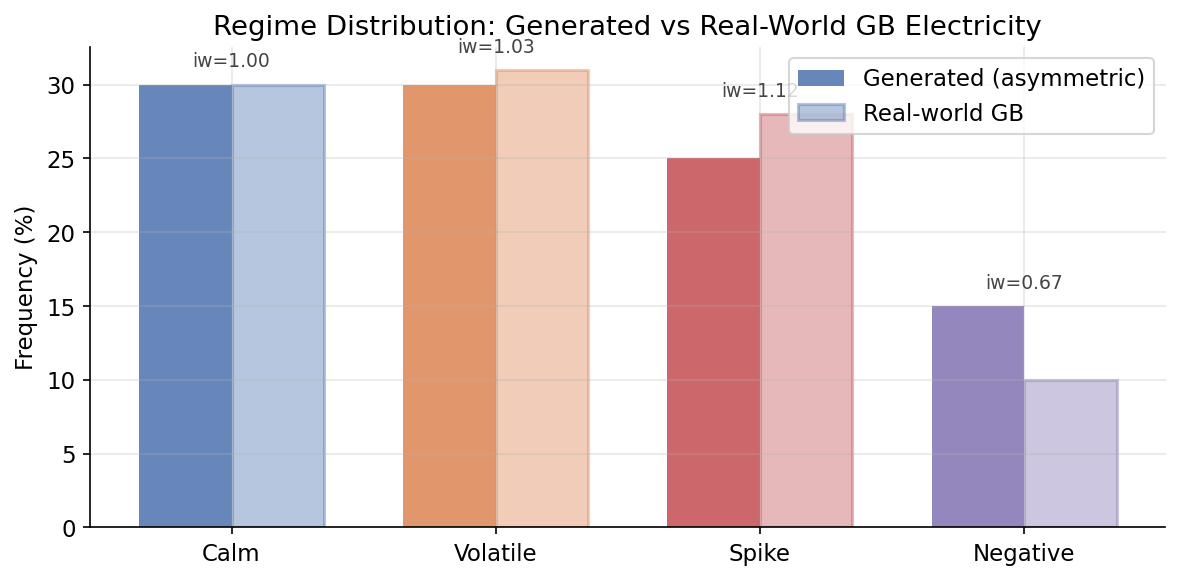

  regime  generated_count  generated_fraction  real_world_fraction  importance_weight
    calm             3000                0.30                 0.30             1.0000
volatile             3000                0.30                 0.31             1.0333
   spike             2500                0.25                 0.28             1.1200
negative             1500                0.15                 0.10             0.6667


In [52]:
df_rw = con.execute("""
    SELECT
        regime,
        generated_count,
        generated_fraction,
        real_world_fraction,
        importance_weight
    FROM regime_weights
    ORDER BY regime_id
""").df()

fig, ax = plt.subplots(figsize=(8, 4))

x      = np.arange(len(REGIME_ORDER))
width  = 0.35
labels = REGIME_ORDER

gen_fracs  = [df_rw.loc[df_rw.regime == r, "generated_fraction"].values[0]  for r in labels]
real_fracs = [df_rw.loc[df_rw.regime == r, "real_world_fraction"].values[0] for r in labels]

bars1 = ax.bar(x - width/2, [f*100 for f in gen_fracs],  width,
               label="Generated (asymmetric)",
               color=[REGIME_COLOURS[r] for r in labels], alpha=0.85)
bars2 = ax.bar(x + width/2, [f*100 for f in real_fracs], width,
               label="Real-world GB",
               color=[REGIME_COLOURS[r] for r in labels], alpha=0.40,
               edgecolor=[REGIME_COLOURS[r] for r in labels], linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels([r.capitalize() for r in labels])
ax.set_ylabel("Frequency (%)")
ax.set_title("Regime Distribution: Generated vs Real-World GB Electricity")
ax.legend()

# Annotate importance weights
for i, r in enumerate(labels):
    iw = df_rw.loc[df_rw.regime == r, "importance_weight"].values[0]
    ax.text(i, max(gen_fracs[i], real_fracs[i]) * 100 + 1.2,
            f"iw={iw:.2f}", ha="center", fontsize=9, color="#444")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_regime_distribution.png", dpi=150)
plt.show()
print(df_rw.to_string(index=False))

## Cell 5 — Section 2: Conditioning scalars by regime

Broken down by regime.
These were the scalar conditioning inputs to the CVAE; the distributions
here reflect what the model was conditioned on for each regime.

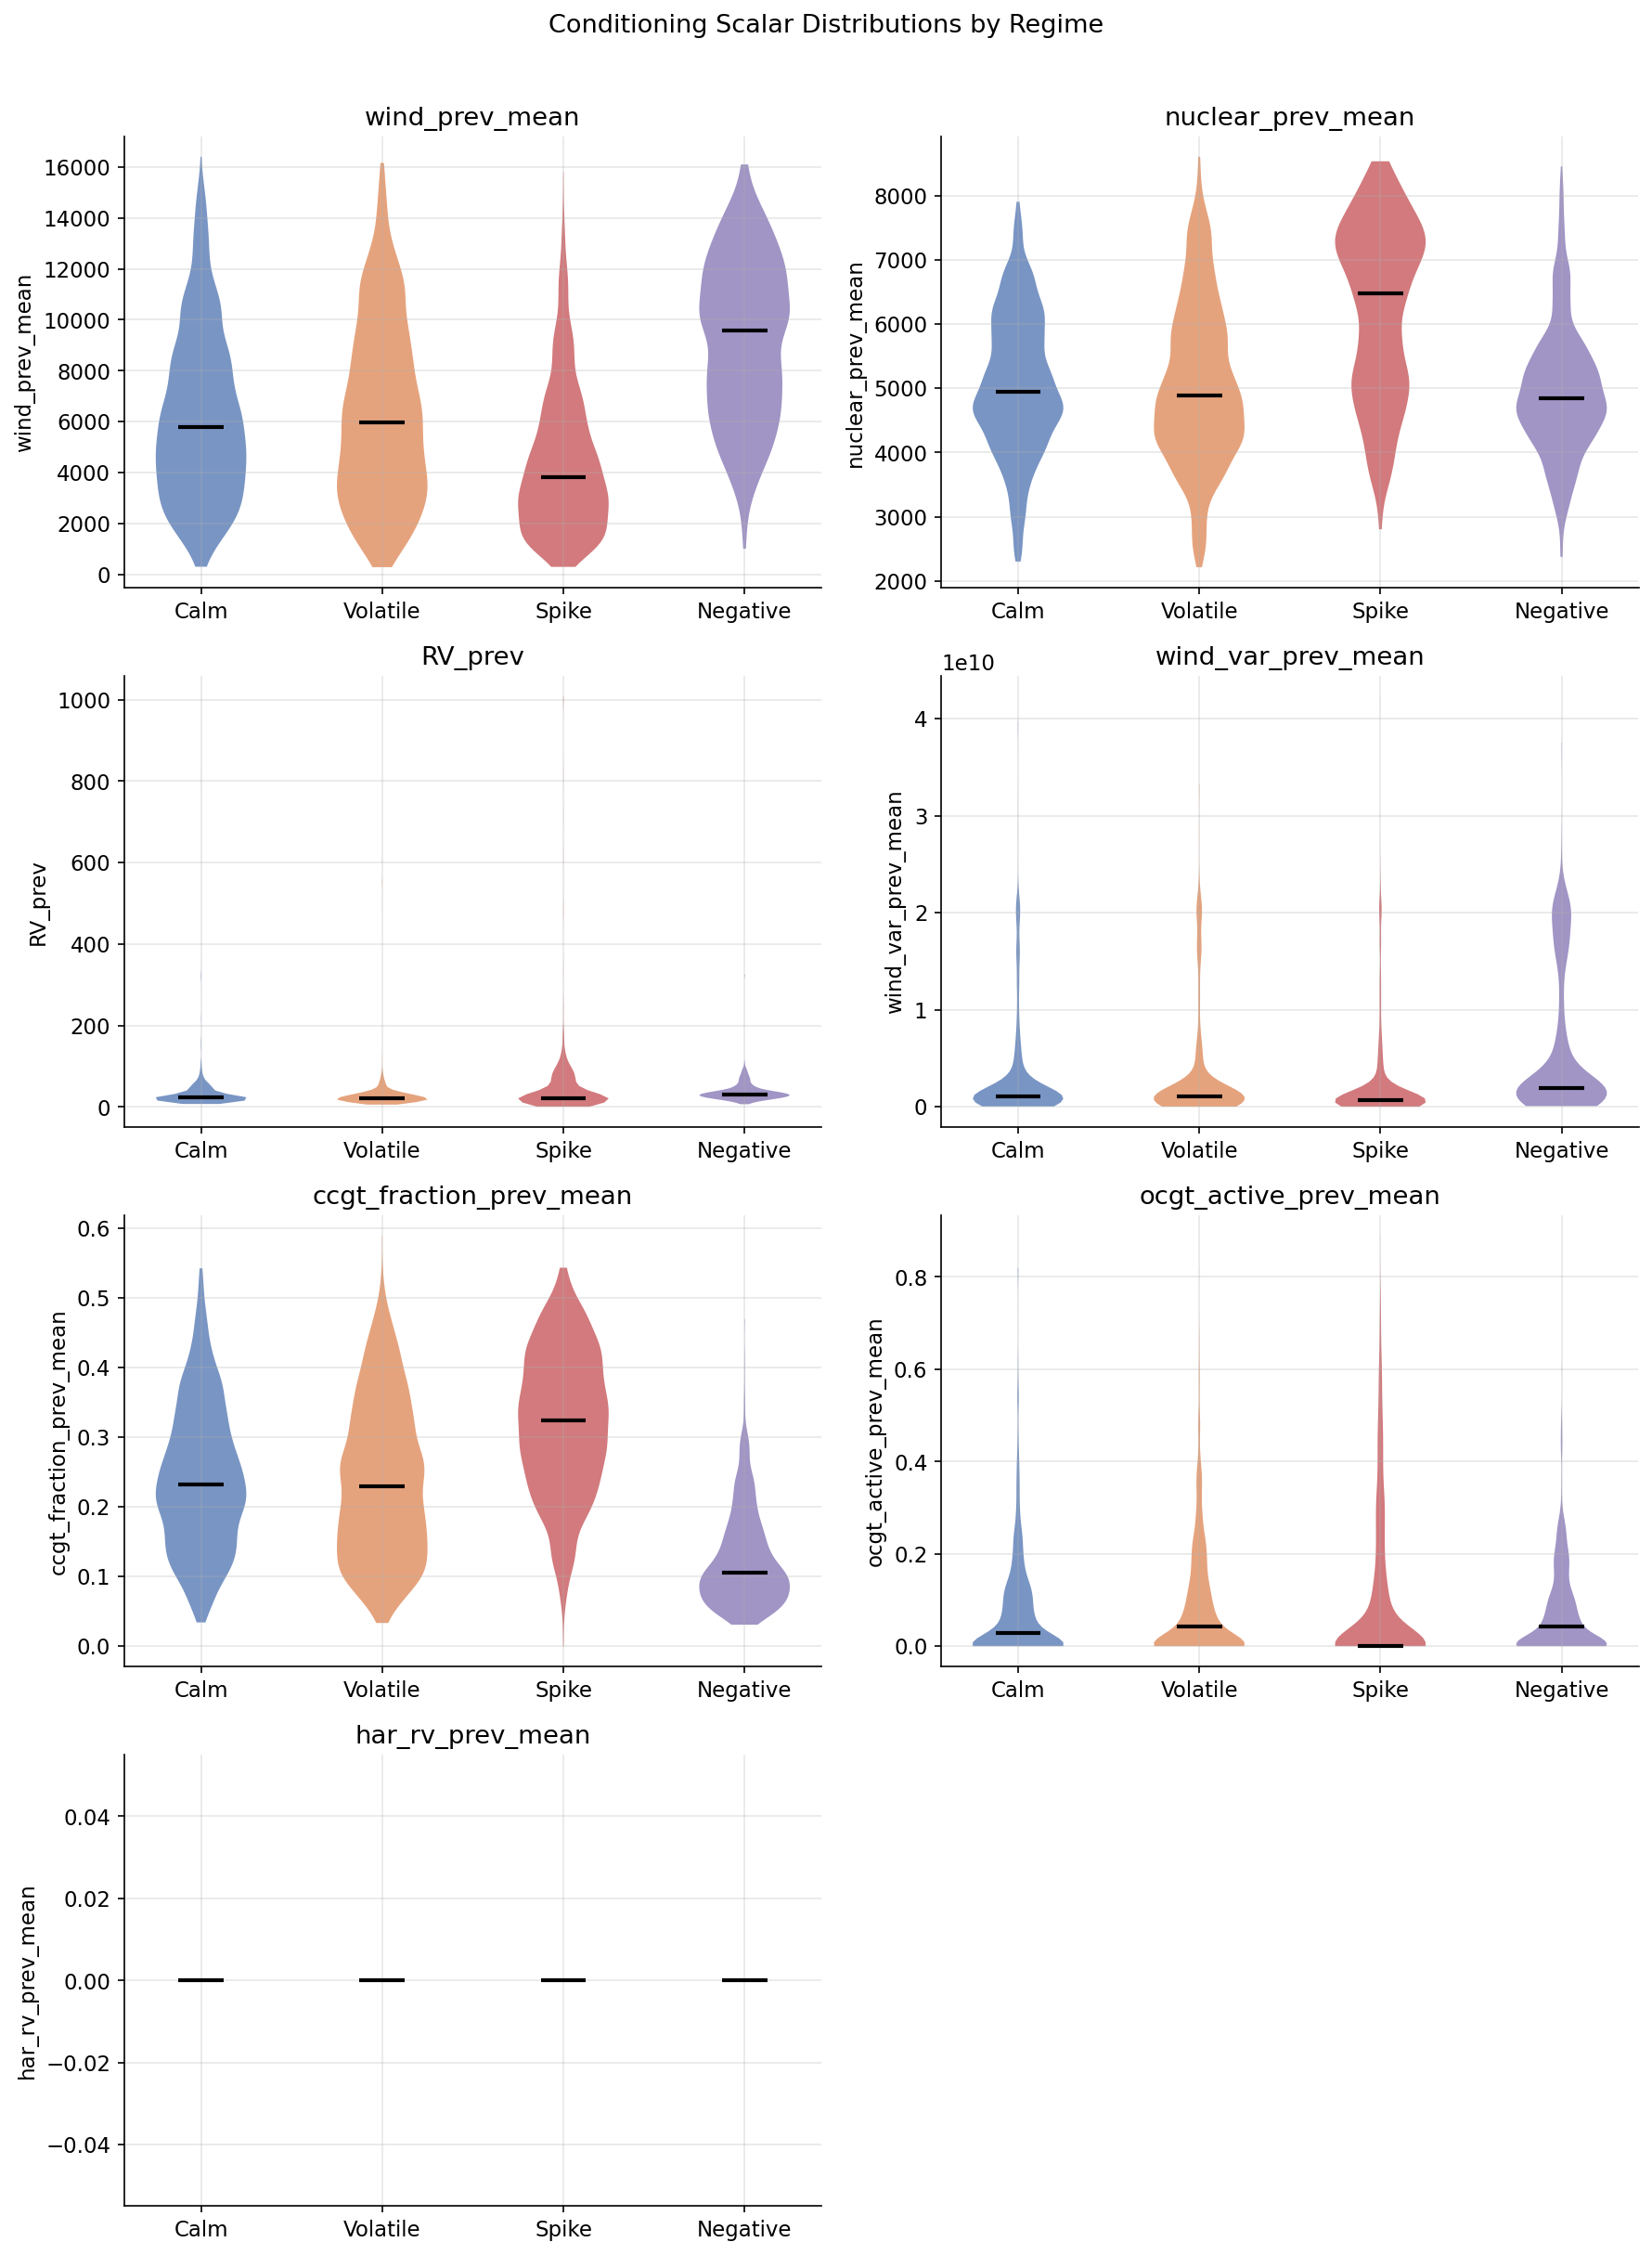

In [61]:
# Load raw data for violin plots — dynamic scalar columns
scalar_select = ", ".join(SCALAR_COND_NAMES)
df_raw = con.execute(f"SELECT regime, {scalar_select} FROM scenarios").df()

n_scalars = len(SCALAR_COND_NAMES)
n_cols = 2
n_rows = (n_scalars + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten() if n_scalars > 1 else [axes]

for i, col in enumerate(SCALAR_COND_NAMES):
    ax = axes[i]
    data_by_regime = [
        df_raw.loc[df_raw.regime == r, col].dropna().values
        for r in REGIME_ORDER
    ]
    parts = ax.violinplot(data_by_regime, positions=range(4),
                          showmedians=True, showextrema=False)
    for pc, r in zip(parts["bodies"], REGIME_ORDER):
        pc.set_facecolor(REGIME_COLOURS[r])
        pc.set_alpha(0.75)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(2)

    ax.set_xticks(range(4))
    ax.set_xticklabels([r.capitalize() for r in REGIME_ORDER])
    ax.set_ylabel(col)
    ax.set_title(col)

# Hide any unused subplots
for j in range(n_scalars, len(axes)):
    axes[j].axis("off")

fig.suptitle("Conditioning Scalar Distributions by Regime", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_conditioning_scalars_by_regime.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 6 — Section 3: Log-signature distributions by regime

Box plots for the first 8 active log-sig dimensions.
Well-separated boxes indicate the CVAE has learned regime-conditional
structure in path space, not just scalar differences.

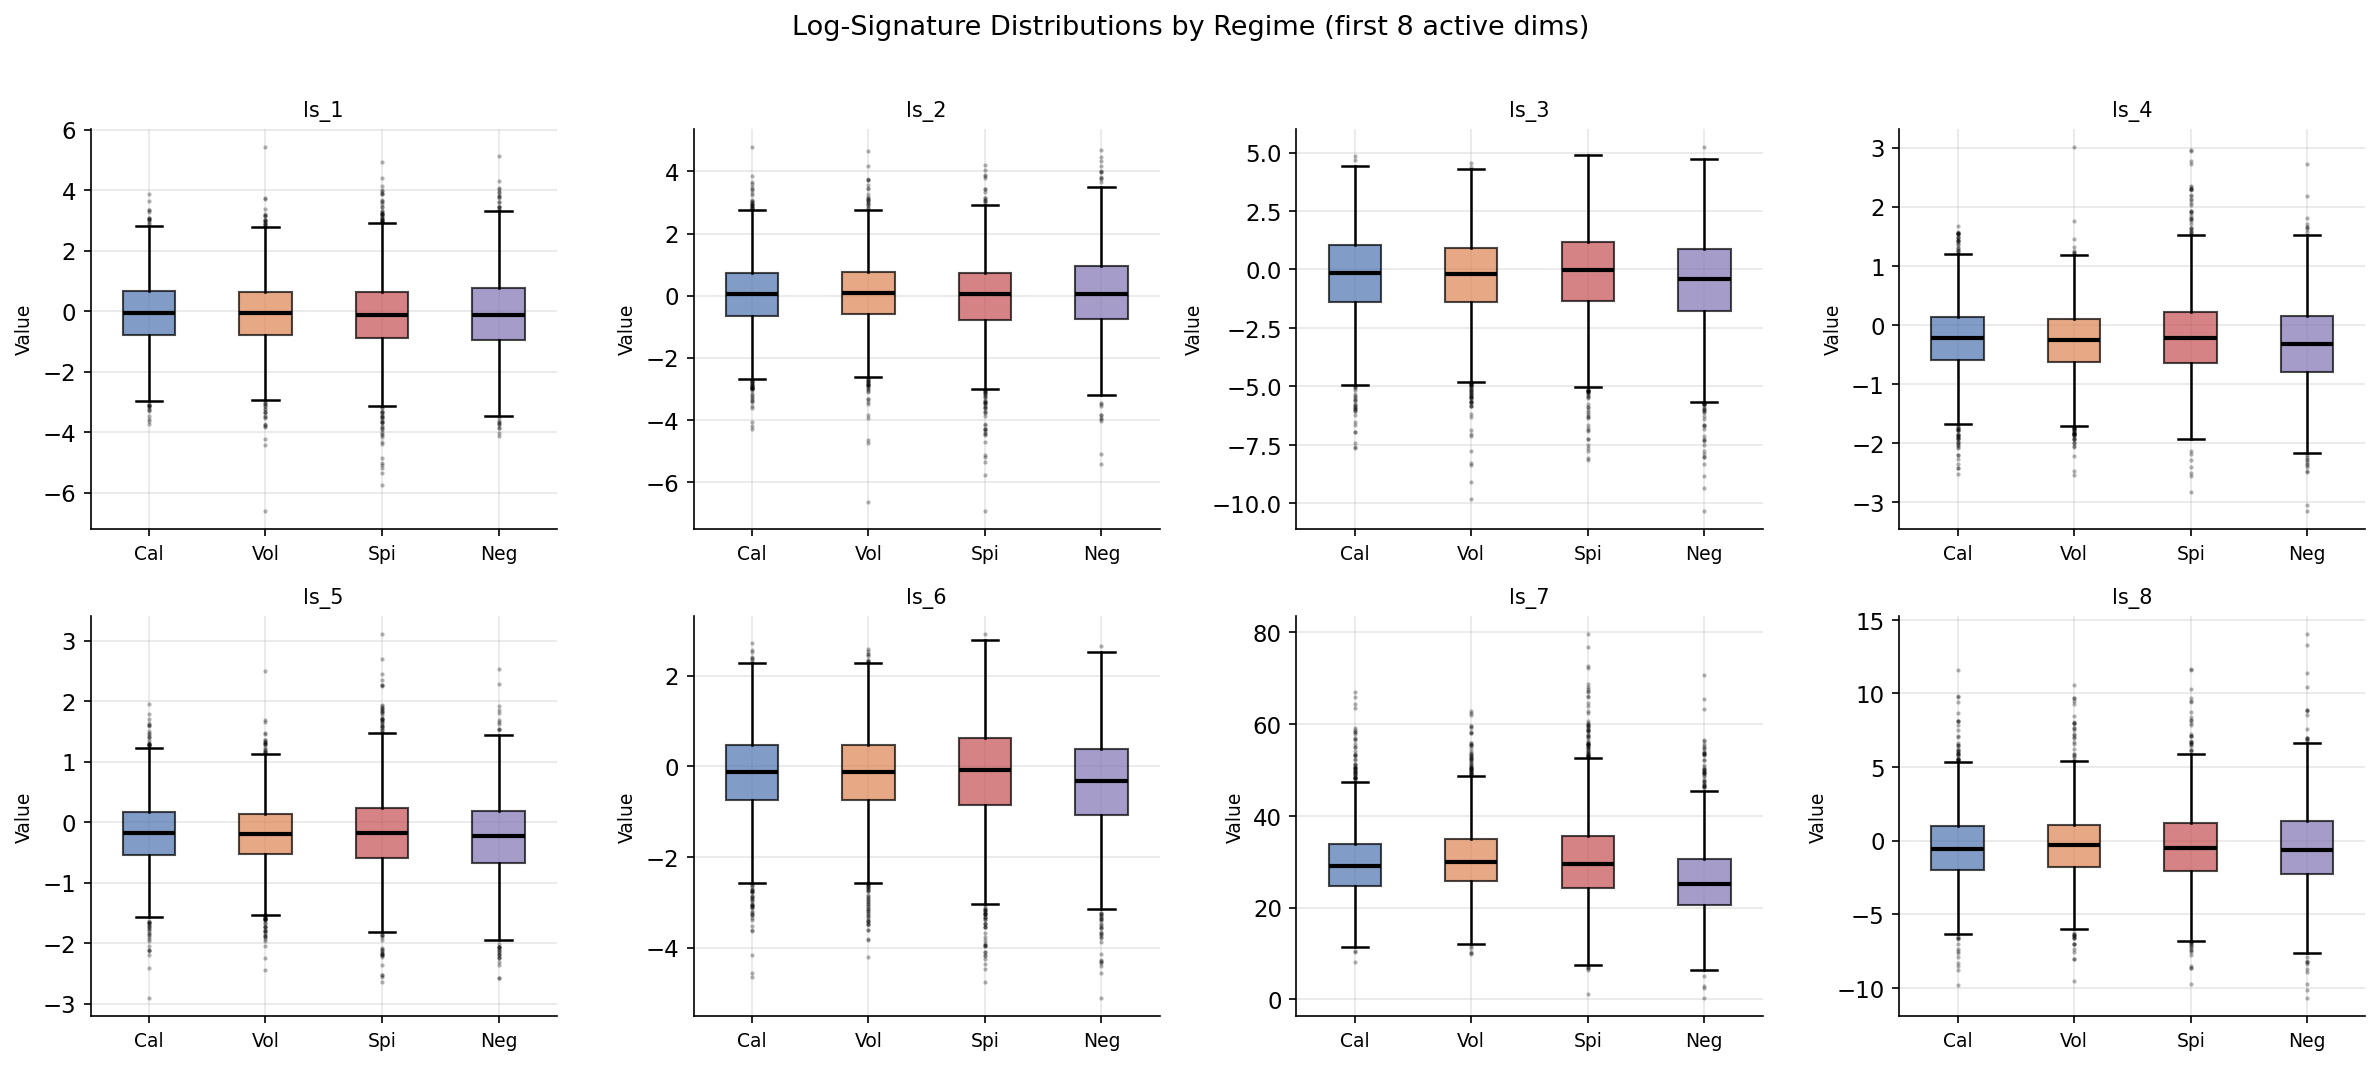

In [55]:
# Use first 8 ls_ columns for readability
plot_ls_cols = ls_cols[:8]

df_ls = con.execute(f"""
    SELECT regime, {', '.join(plot_ls_cols)}
    FROM scenarios
""").df()

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, col in zip(axes, plot_ls_cols):
    data_by_regime = [
        df_ls.loc[df_ls.regime == r, col].values for r in REGIME_ORDER
    ]
    bp = ax.boxplot(
        data_by_regime,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
        flierprops=dict(marker=".", markersize=2, alpha=0.3),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
    )
    for patch, r in zip(bp["boxes"], REGIME_ORDER):
        patch.set_facecolor(REGIME_COLOURS[r])
        patch.set_alpha(0.7)
    ax.set_xticks(range(1, 5))
    ax.set_xticklabels([r[:3].capitalize() for r in REGIME_ORDER], fontsize=9)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("Value", fontsize=9)

fig.suptitle(
    "Log-Signature Distributions by Regime (first 8 active dims)",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_logsig_distributions_by_regime.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 7 — Section 4: Importance-weighted reweighting

Compares raw (asymmetrically sampled) means against importance-weighted
means for each scalar. The weighted means should recover real-world averages.
This validates the reweighting logic before 07a/07d rely on it.

Raw vs importance-weighted scalar means:
  wind_prev_mean                     : raw= 6269.2068  weighted= 6064.1419
  nuclear_prev_mean                  : raw= 5337.4850  weighted= 5381.6317
  RV_prev                            : raw=   34.2863  weighted=   34.4136
  wind_var_prev_mean                 : raw=3471537396.6127  weighted=3296158333.1659
  ccgt_fraction_prev_mean            : raw=    0.2425  weighted=    0.2507
  ocgt_active_prev_mean              : raw=    0.0864  weighted=    0.0878
  har_rv_prev_mean                   : raw=    0.0000  weighted=    0.0000


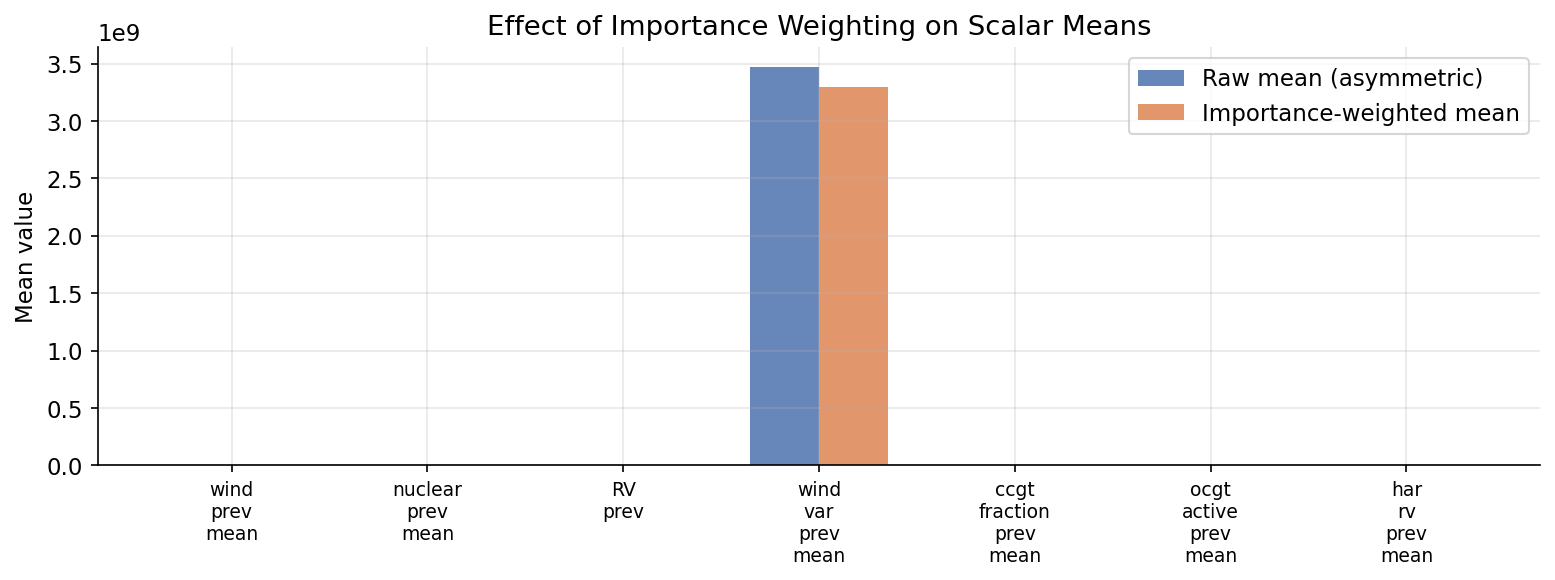

In [62]:
print("Raw vs importance-weighted scalar means:")
raw_vals, iw_vals = [], []
for col in SCALAR_COND_NAMES:
    df_wt = con.execute(f"""
        SELECT
            ROUND(AVG({col}), 4) AS raw_mean,
            ROUND(SUM({col} * importance_weight) / SUM(importance_weight), 4) AS weighted_mean
        FROM scenarios_weighted
    """).df()
    raw = float(df_wt["raw_mean"].iloc[0])
    wt  = float(df_wt["weighted_mean"].iloc[0])
    raw_vals.append(raw)
    iw_vals.append(wt)
    print(f"  {col:35s}: raw={raw:>10.4f}  weighted={wt:>10.4f}")

fig, ax = plt.subplots(figsize=(max(10, 1.5 * len(SCALAR_COND_NAMES)), 4))
x = np.arange(len(SCALAR_COND_NAMES))
width = 0.35

ax.bar(x - width/2, raw_vals, width, label="Raw mean (asymmetric)", color="#4C72B0", alpha=0.85)
ax.bar(x + width/2, iw_vals,  width, label="Importance-weighted mean", color="#DD8452", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([m.replace("_", "\n") for m in SCALAR_COND_NAMES], fontsize=9)
ax.set_title("Effect of Importance Weighting on Scalar Means")
ax.set_ylabel("Mean value")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "04_importance_weighting_effect.png", dpi=150)
plt.show()

## Cell 8 — Section 5: Log-signature correlation structure by regime

Heatmaps of the Pearson correlation matrix of log-sig dimensions,
one per regime. Structural differences across regimes reveal that
the CVAE has learned distinct path geometries per regime —
not just shifted means.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, regime in zip(axes, REGIME_ORDER):
    df_r = con.execute(f"""
        SELECT {', '.join(ls_cols)}
        FROM scenarios
        WHERE regime = '{regime}'
    """).df()

    corr = df_r.corr()

    sns.heatmap(
        corr,
        ax=ax,
        cmap="RdBu_r",
        vmin=-1, vmax=1,
        center=0,
        xticklabels=False,
        yticklabels=False,
        cbar_kws={"shrink": 0.7},
        square=True,
    )
    n_regime = len(df_r)
    ax.set_title(
        f"{regime.capitalize()} (n={n_regime:,})",
        color=REGIME_COLOURS[regime],
        fontsize=12, fontweight="bold"
    )

fig.suptitle(
    "Log-Signature Correlation Structure by Regime (31 active dims)",
    fontsize=13
)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_logsig_correlation_by_regime.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 9 — Section 6: Scenario sampling patterns

Demonstrates the exact query patterns that 07a and 07d will use.
Validates that random sampling, regime filtering, and reweighted
sampling all work correctly from the live database.

In [ ]:
# ── Pattern A: full log-sig matrix (for batch decoding in 07d) ────────────────
X_dict  = con.execute(f"SELECT {', '.join(ls_cols)} FROM scenarios ORDER BY scenario_id").fetchnumpy()
X_all   = np.stack([X_dict[c] for c in ls_cols], axis=1)
print(f"Pattern A — full log-sig matrix: {X_all.shape}")

# ── Pattern B: regime-filtered (for 07a gas storage control) ─────────────────
for regime in REGIME_ORDER:
    n = con.execute(f"SELECT COUNT(*) FROM scenarios WHERE regime = '{regime}'").fetchone()[0]
    df_sample = con.execute(f"""
        SELECT scenario_id, regime, {', '.join(ls_cols[:3])}
        FROM scenarios
        WHERE regime = '{regime}'
        USING SAMPLE 5 ROWS
    """).df()
    print(f"Pattern B — sample_regime('{regime}', n=5): {df_sample.shape}  (pool={n:,})")

# ── Pattern C: importance-weighted full sample (for 07d unbiased CVaR) ────────
df_wt = con.execute(f"""
    SELECT scenario_id, regime, importance_weight, {', '.join(ls_cols[:3])}
    FROM scenarios_weighted
    ORDER BY scenario_id
""").df()
print(f"\nPattern C — weighted sample: {df_wt.shape}")
print(f"  Importance weight range: [{df_wt.importance_weight.min():.3f}, {df_wt.importance_weight.max():.3f}]")

# ── Pattern D: retrieve model config (for loading CVAE decoder) ───────────────
print("\nPattern D — model config retrieval:")
for key in ["latent_dim", "hidden_dim", "n_layers", "cond_dim", "logsig_dim", "best_val_loss"]:
    val = con.execute(f"SELECT value FROM model_config WHERE key = '{key}'").fetchone()[0]
    print(f"  {key:<20} {val}")

## Cell 10 — Summary statistics table

A clean printable summary for the dissertation / README.

In [63]:
# Build the scalar averages dynamically so any conditioning vector works
scalar_avg_sql = ",\n        ".join(
    f"ROUND(AVG(s.{c}), 3) AS avg_{c}" for c in SCALAR_COND_NAMES
)

df_summary = con.execute(f"""
    SELECT
        s.regime,
        COUNT(*)                               AS n_scenarios,
        ROUND(100.0 * COUNT(*) / 10000, 1)     AS pct_generated,
        ROUND(rw.real_world_fraction * 100, 1) AS pct_real_world,
        ROUND(rw.importance_weight, 3)         AS importance_weight,
        {scalar_avg_sql}
    FROM scenarios s
    JOIN regime_weights rw ON s.regime = rw.regime
    GROUP BY s.regime, rw.regime_id, rw.real_world_fraction, rw.importance_weight
    ORDER BY rw.regime_id
""").df()

print("=" * 75)
print("SCENARIO DATABASE SUMMARY")
print("=" * 75)
print(df_summary.to_string(index=False))
print("=" * 75)

# Validation summary
print("\nModel validation (notebook 05):")
df_val = con.execute("""
    SELECT metric, result FROM validation_summary
    WHERE metric NOT IN ('notes')
""").df()
for _, row in df_val.iterrows():
    print(f"  {row['metric']:<25} {row['result']}")

SCENARIO DATABASE SUMMARY
  regime  n_scenarios  pct_generated  pct_real_world  importance_weight  avg_wind_prev_mean  avg_nuclear_prev_mean  avg_RV_prev  avg_wind_var_prev_mean  avg_ccgt_fraction_prev_mean  avg_ocgt_active_prev_mean  avg_har_rv_prev_mean
    calm         3000           30.0            30.0              1.000            6221.996               5056.054       31.014            3.207334e+09                        0.241                      0.079                   0.0
volatile         3000           30.0            31.0              1.033            6350.178               5069.481       27.122            3.384104e+09                        0.238                      0.088                   0.0
   spike         2500           25.0            28.0              1.120            4440.857               6231.554       45.239            2.257412e+09                        0.321                      0.104                   0.0
negative         1500           15.0            10.0  

## Cell 11 — Close connection and report saved figures

In [64]:
con.close()

print("Figures saved to:", FIG_DIR)
for fp in sorted(FIG_DIR.glob("*.png")):
    print(f"  {fp.name}  ({fp.stat().st_size / 1024:.1f} KB)")

print("\nNotebook 07b complete.")
print("Next: 07a (gas storage stochastic control)")

Figures saved to: /content/drive/MyDrive/energy_synthetic_data/data/figures
  01_regime_distribution.png  (52.2 KB)
  02_conditioning_scalars_by_regime.png  (275.8 KB)
  03_logsig_distributions_by_regime.png  (123.6 KB)
  04_importance_weighting_effect.png  (52.1 KB)
  05_logsig_correlation_by_regime.png  (102.5 KB)

Notebook 07b complete.
Next: 07a (gas storage stochastic control)
